In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.usetex'] = False  

# How to use `GREApy`

In [3]:
from greapy import GREA

# Create an instance of the GREA model
cosmo = GREA()
cosmo

GREA(h=0.6736, omega_cdm=0.12, omega_b=0.02237, kappa=3.55, omega_g=2.47739e-05, Neff=3.044, a_min=1e-11)

One important thing to note, is that the parameter $H_0\equiv H(z=0)\neq H^{\Lambda\rm CDM}_0=100h$. Indeed, depending on the value of the curvature scale $\sqrt{-k}\eta_0$ (or equivalently, $\alpha$), the predicted $H_0$ can be larger than the $\Lambda\rm CDM$ 

In [ ]:
cosmo.H0, 100*cosmo.h

(66.97578547836822, 67.36)

Thus, the (derived) fractional energy densities are defined as $\Omega_{i}(z)\equiv\frac{8\pi G}{3H(z)^2}\rho_i(z)$. In particular, the present day values are given by $\Omega_{i,0}=\frac{8\pi G}{3H(z=0)^2}\rho_{i,0}$

In [5]:
cosmo.Omega_m

0.3173824101534147

(0.01, 1000.0)

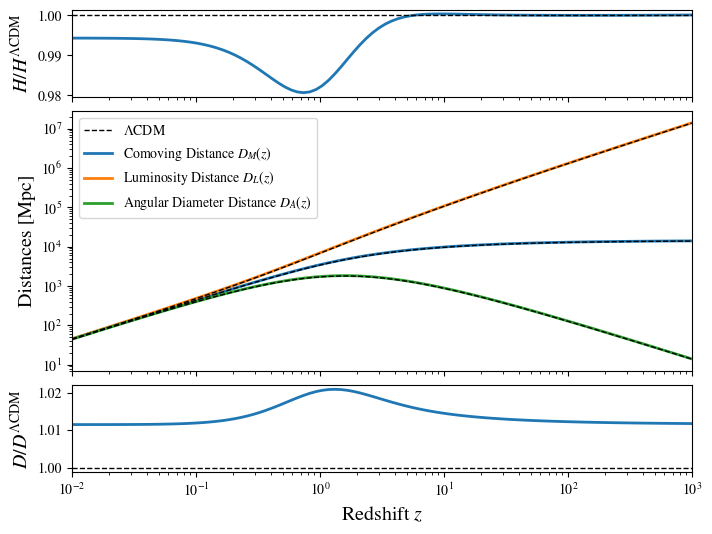

In [13]:
z=np.logspace(-2, 3, 100)

def plot_distances(z,model):
    
    from astropy.cosmology import FlatLambdaCDM
    lcdm = FlatLambdaCDM(H0=100*model.h, Om0=model.Omega_bc,Ob0=model.omega_b/model.h**2, Tcmb0=2.7259, Neff=3.044)
    
    fig,(ax_H,ax_obs,ax_res)=plt.subplots(3,1,sharex=True,figsize=(8, 6),gridspec_kw={'height_ratios': [1 ,3, 1],'hspace': 0.1 })
    ax_obs.plot([],[],label='$\Lambda$CDM', color='k', linestyle='--', lw=1)
    
    for m, kwargs in zip([model, lcdm], [{'lw': 2}, {'linestyle': '--', 'c': 'k', 'lw': 1.}]):
        ax_H.plot(z, m.H(z)/lcdm.H(z).value, **kwargs)
        ax_obs.plot(z, m.comoving_distance(z), label='Comoving Distance $D_M(z)$',**kwargs)
        ax_obs.plot(z, m.luminosity_distance(z), label='Luminosity Distance $D_L(z)$',**kwargs)
        ax_obs.plot(z, m.angular_diameter_distance(z), label='Angular Diameter Distance $D_A(z)$',**kwargs)
        if m is model: ax_obs.legend()
    ax_res.plot(z, model.comoving_distance(z)/lcdm.comoving_distance(z).value,lw=2.)
    ax_res.axhline(1, color='k', lw=1, ls='--')
    ax_obs.loglog()
    ax_H.set_ylabel(r'$H/H^{\Lambda\rm CDM}$',fontsize='x-large')
    ax_obs.set_ylabel('Distances [Mpc]', fontsize='x-large')
    ax_res.set_ylabel(r'$D/D^{\Lambda\rm CDM}$', fontsize='x-large')
    ax_res.set_xlabel('Redshift $z$',fontsize='x-large')
    return plt.gca()

ax=plot_distances(z, cosmo)
ax.set_xlim(z.min(),z.max())

``GREApy`` can also compute the corresponding values of the sound horizon at recombination $r_s(z_{\rm rec})$ and drag epoch $r_d\equiv r_s(z_{\rm drag})$ 

In [14]:
cosmo.rs_rec,cosmo.rdrag

(144.5055213020333, 147.07705249598033)

In [15]:
100*cosmo.thetastar

1.0279674033800361

That's it! You've got everything you need to start sampling the posterior distribution of GREA and reproduce the results in our recent analysis!